In [ ]:
# Install required libraries
!pip install transformers datasets scikit-learn torch tqdm

In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset, DatasetDict

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_parquet("/content/drive/MyDrive/NLP Final Project/clean_news_data.parquet")

print(df.shape)

(146876, 10)


In [ ]:
df.head(3)

,news_id,url,date,language,title,text,char_count,word_count,is_english,clean_text
0,0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","bad idea ai price (bad), , & chart history - b...",3501,483,True,bad idea ai price bad chart history blockworks...
1,1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,this ai video of gymnastics might be the freak...,5585,812,True,ai video gymnastic freaky see boe boe blog pos...
2,2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","if using ai feels like a chore, try this - boi...",5880,884,True,ai feel like chore try boe boe blog post forum...


In [ ]:
external_ai_news_df = pd.read_csv("/content/drive/MyDrive/NLP Final Project/FinancialPhraseBank.csv")

In [ ]:
external_ai_news_df.head(3)

,headline,sentiment,char_count,word_count
0,"According to Gran , the company has no plans t...",neutral,127,25
1,With the new production plant the company woul...,positive,206,33
2,"For the last quarter of 2010 , Componenta 's n...",positive,193,39


In [ ]:
external_ai_news_df.shape

(3453, 4)

In [ ]:
external_ai_news_df = external_ai_news_df.rename(columns={'text': 'headline'})

In [ ]:
# Keep only relevant columns
external_ai_news_df = external_ai_news_df[['headline', 'sentiment']]

# Map sentiment to integers
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
external_ai_news_df['label'] = external_ai_news_df['sentiment'].map(label_mapping)


/tmp/ipykernel_3506/4128216869.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  external_ai_news_df['label'] = external_ai_news_df['sentiment'].map(label_mapping)


In [ ]:
external_ai_news_df['label'].value_counts()

,count
label,
1,2146
2,887
0,420


In [ ]:
# ----------------------------
# Step 3: Split into Train, Val, Test
# ----------------------------
train_df, temp_df = train_test_split(
    external_ai_news_df,
    test_size=0.3,
    stratify=external_ai_news_df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

Train: (2417, 3), Val: (518, 3), Test: (518, 3)


In [ ]:
# ----------------------------
# Step 4: Convert to HuggingFace Datasets
# ----------------------------
train_dataset = Dataset.from_pandas(train_df[['headline','label']])
val_dataset = Dataset.from_pandas(val_df[['headline','label']])
test_dataset = Dataset.from_pandas(test_df[['headline','label']])

dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

# ----------------------------
# Step 5: Tokenization
# ----------------------------
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(batch['headline'], padding=True, truncation=True, max_length=512)

tokenized_datasets = dataset_dict.map(tokenize, batched=True)
tokenized_datasets.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/2417 [00:00<?, ? examples/s]

Map:   0%|          | 0/518 [00:00<?, ? examples/s]

Map:   0%|          | 0/518 [00:00<?, ? examples/s]

## Train distilbert-base-uncased model (learning_rate=2e-5, num_train_epochs=3)

In [ ]:
# ----------------------------
# Step 6: Load model
# ----------------------------
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import DataCollatorWithPadding

# ----------------------------
# Step 7: Training
# ----------------------------
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs',
    logging_steps=50,
)

# Initialize DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator, # Add data collator here
)

trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.329067,0.270072
2,0.192135,0.230759
3,0.096626,0.256523


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=456, training_loss=0.2847343521159992, metrics={'train_runtime': 1526.9282, 'train_samples_per_second': 4.749, 'train_steps_per_second': 0.299, 'total_flos': 225115023950154.0, 'train_loss': 0.2847343521159992, 'epoch': 3.0})

In [ ]:
# ----------------------------
# Step 8: Evaluation
# ----------------------------
preds_output = trainer.predict(tokenized_datasets['test'])
preds = preds_output.predictions.argmax(-1)
print(classification_report(test_df['label'], preds, target_names=['Negative','Neutral','Positive']))


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    Negative       0.96      0.78      0.86        63
     Neutral       0.94      0.98      0.96       322
    Positive       0.89      0.87      0.88       133

    accuracy                           0.93       518
   macro avg       0.93      0.88      0.90       518
weighted avg       0.93      0.93      0.93       518



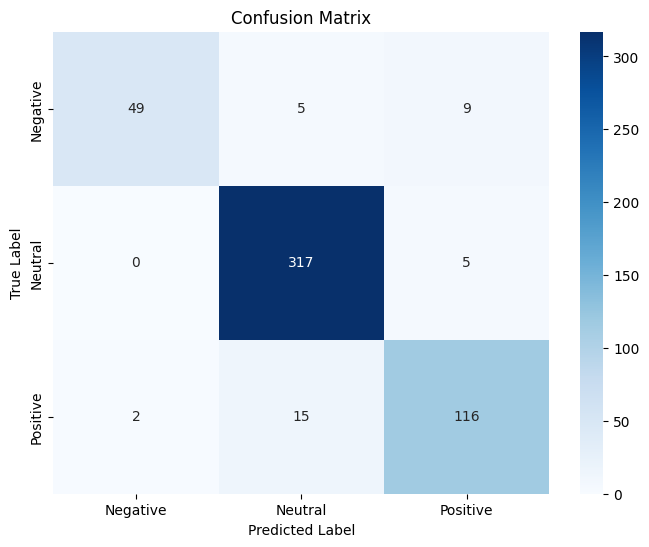

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_df['label'], preds)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
output_dir = "/content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v1"

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v1


In [ ]:
test_df['predicted_label'] = preds

# Define reverse_label_mapping
reverse_label_mapping = {v: k for k, v in label_mapping.items()}
test_df['predicted_sentiment'] = test_df['predicted_label'].map(reverse_label_mapping)

misclassified_neutral_df = test_df[
    (test_df['label'] == 1) & (test_df['predicted_label'] != 1)
].copy()

print("Misclassified Neutral Samples:")
display(misclassified_neutral_df[['headline', 'sentiment', 'predicted_sentiment']].head())

Misclassified Neutral Samples:


,headline,sentiment,predicted_sentiment
2519,"Following the issue , the number of shares in ...",neutral,positive
1863,Aldata noted that its Voice Supply Chain Techn...,neutral,positive
3426,Because expenditures must be justified to pass...,neutral,positive
2959,`` We have the most expensive water brand in F...,neutral,positive
2326,"The share sale , to foreign and Finnish invest...",neutral,positive


## Bert-base-uncased (learning_rate=2e-5, num_train_epochs=3)

In [ ]:
model_bert_uncased = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)
print("BERT-base-uncased model reloaded for full dataset training.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT-base-uncased model reloaded for full dataset training.


In [ ]:
tokenizer_bert = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_bert(batch):
    return tokenizer_bert(batch['headline'], padding=True, truncation=True, max_length=512)

tokenized_datasets_bert = dataset_dict.map(tokenize_bert, batched=True)
tokenized_datasets_bert.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Dataset tokenized with bert-base-uncased tokenizer.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/2417 [00:00<?, ? examples/s]

Map:   0%|          | 0/518 [00:00<?, ? examples/s]

Map:   0%|          | 0/518 [00:00<?, ? examples/s]

Dataset tokenized with bert-base-uncased tokenizer.


In [ ]:
# Define class weights tensor for the BERT model
class_weights = [1.0, 1, 1.0] # Using the last adjusted weights for Neutral class
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)


In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import torch.nn as nn
import torch

# Re-define CustomTrainer class to ensure it's available
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Apply class weights to the loss function
        # Ensure class_weights_tensor is on the same device as the model
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# Initialize DataCollatorWithPadding for the BERT tokenizer
data_collator_bert = DataCollatorWithPadding(tokenizer=tokenizer_bert)

training_args_bert = TrainingArguments(
    output_dir="./results_bert_tuned",  # New output directory for BERT
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,  # Tuned learning rate
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,  # Increased epochs
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs_bert_tuned',  # New logging directory for BERT
    logging_steps=50,
)

trainer_bert_uncased = CustomTrainer(
    model=model_bert_uncased,
    args=training_args_bert,
    train_dataset=tokenized_datasets_bert['train'],
    eval_dataset=tokenized_datasets_bert['validation'],
    data_collator=data_collator_bert, # Pass the data collator here
)

trainer_bert_uncased.train()
print("BERT model retrained with tuned hyperparameters and adjusted class weights on full dataset.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.313099,0.203778
2,0.195968,0.223573
3,0.098834,0.252116


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

BERT model retrained with tuned hyperparameters and adjusted class weights on full dataset.


In [ ]:
# ----------------------------
# Step 8: Evaluation
# ----------------------------
preds_output = trainer_bert_uncased.predict(tokenized_datasets['test'])
preds = preds_output.predictions.argmax(-1)
print(classification_report(test_df['label'], preds, target_names=['Negative','Neutral','Positive']))


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    Negative       0.90      0.87      0.89        63
     Neutral       0.93      0.99      0.96       322
    Positive       0.95      0.80      0.87       133

    accuracy                           0.93       518
   macro avg       0.93      0.89      0.90       518
weighted avg       0.93      0.93      0.93       518



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


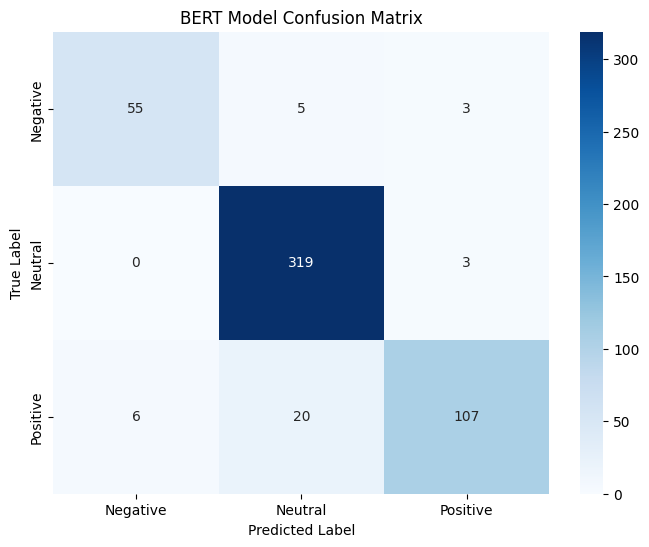

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

preds_output_bert = trainer_bert_uncased.predict(tokenized_datasets_bert['test'])
preds_bert = preds_output_bert.predictions.argmax(-1)

cm_bert = confusion_matrix(test_df['label'], preds_bert)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('BERT Model Confusion Matrix')
plt.show()

In [ ]:
output_dir = "/content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_bert_uncased_v1"

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_bert_uncased_v1


## Roberta model (learning_rate=2e-5, num_train_epochs=3)

In [ ]:
class_weights = [1.0, 1.0, 1.0] # Equal weights for Negative (0), Neutral (1), Positive (2)
print(f"Defined class weights: {class_weights}")

# Convert to torch tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights tensor: {class_weights_tensor}")

Defined class weights: [1.0, 1.0, 1.0]
Class weights tensor: tensor([1., 1., 1.])


In [ ]:
def tokenize_roberta(batch):
    return tokenizer_roberta(batch['headline'], padding=True, truncation=True, max_length=512)

tokenized_datasets_roberta = dataset_dict.map(tokenize_roberta, batched=True)
tokenized_datasets_roberta.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Dataset tokenized with RoBERTa tokenizer.")

Map:   0%|          | 0/2417 [00:00<?, ? examples/s]

Map:   0%|          | 0/518 [00:00<?, ? examples/s]

Map:   0%|          | 0/518 [00:00<?, ? examples/s]

Dataset tokenized with RoBERTa tokenizer.


In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
import torch.nn as nn

# Re-define CustomTrainer class to ensure it's available
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Apply class weights to the loss function
        # Ensure class_weights_tensor is on the same device as the model
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# Initialize DataCollatorWithPadding for the RoBERTa tokenizer
data_collator_roberta = DataCollatorWithPadding(tokenizer=tokenizer_roberta)

training_args_roberta = TrainingArguments(
    output_dir="./results_roberta_v1",  # New output directory for RoBERTa
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,  # Specified learning rate
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,  # Specified number of epochs
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs_roberta_v1',  # New logging directory for RoBERTa
    logging_steps=50,
)

trainer_roberta = CustomTrainer(
    model=model_roberta,
    args=training_args_roberta,
    train_dataset=tokenized_datasets_roberta['train'],
    eval_dataset=tokenized_datasets_roberta['validation'],
    data_collator=data_collator_roberta, # Pass the data collator here
)

trainer_roberta.train()
print("RoBERTa model trained.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.417666,0.293880
2,0.194194,0.239840
3,0.114562,0.264714


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

RoBERTa model trained.


In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the test dataset with the retrained model
preds_output_roberta = trainer_roberta.predict(tokenized_datasets_roberta['test'])
preds_roberta = preds_output_roberta.predictions.argmax(-1)

# Print the classification report
print(classification_report(test_df['label'], preds_roberta, target_names=['Negative', 'Neutral', 'Positive']))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    Negative       1.00      0.76      0.86        63
     Neutral       0.97      0.96      0.96       322
    Positive       0.87      0.97      0.91       133

    accuracy                           0.94       518
   macro avg       0.94      0.90      0.91       518
weighted avg       0.94      0.94      0.94       518



In [ ]:
output_dir = "/content/drive/MyDrive/NLP Final Project/finance_news/sentiment_roberta_v1"

trainer_roberta.save_model(output_dir)
tokenizer_roberta.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/NLP Final Project/finance_news/sentiment_roberta_v1


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer_roberta = AutoTokenizer.from_pretrained("roberta-base")
model_roberta = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=3)

print("RoBERTa tokenizer and model loaded.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa tokenizer and model loaded.


## Fine tuning bert distilled

## Check distilbert-base-uncased Training Set Label Distribution & Misclassified Neutral Samples

In [ ]:
print(train_df['label'].value_counts())

label
1    1502
2     621
0     294
Name: count, dtype: int64


In [ ]:
print(val_df['label'].value_counts())

label
1    322
2    133
0     63
Name: count, dtype: int64


In [ ]:
print(test_df['label'].value_counts())

label
1    322
2    133
0     63
Name: count, dtype: int64


## Fine Tuning Model v2 (learning_rate=2e-5, num_train_epochs=3, Negative weigth = 1.5)

In [ ]:
print("Class frequencies in train_df:")
print(train_df['label'].value_counts())

# Define class weights as per instructions
# Assign a higher weight (e.g., 3.0) to the 'Neutral' class (label 1)
# and a weight of 1.0 to 'Negative' (label 0) and 'Positive' (label 2).
class_weights = [1.5, 1, 1]
print(f"Defined class weights: {class_weights}")

Class frequencies in train_df:
label
1    1502
2     621
0     294
Name: count, dtype: int64
Defined class weights: [1.5, 1, 1]


In [ ]:
import torch

# Convert class_weights list to a torch.Tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights tensor: {class_weights_tensor}")

# Load model again without the 'weight' argument, as it's not directly supported here.
# We will integrate class weights via a custom Trainer.
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
print("Model reloaded without initial class weights. Will apply them in custom Trainer.")

Class weights tensor: tensor([1.5000, 1.0000, 1.0000])


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model reloaded without initial class weights. Will apply them in custom Trainer.


In [ ]:
from transformers import Trainer
import torch.nn as nn

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Apply class weights to the loss function
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

print("CustomTrainer class defined to incorporate class weights.")

CustomTrainer class defined to incorporate class weights.


In [ ]:
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
import torch.nn as nn

# Initialize DataCollatorWithPadding for the distilbert tokenizer
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./results_weighted", # Changed output directory to distinguish from previous training
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs_weighted', # Changed logging directory
    logging_steps=50,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator, # Add the data collator here
)

trainer.train()
print("DistilBERT model with weighted loss has been re-trained with DataCollatorWithPadding.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.347503,0.284203
2,0.210108,0.233958
3,0.113020,0.248370


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


DistilBERT model with weighted loss has been re-trained with DataCollatorWithPadding.


In [ ]:
# ----------------------------
# Step 8: Evaluation (with weighted loss)
# ----------------------------
preds_output_weighted = trainer.predict(tokenized_datasets['test'])
preds_weighted = preds_output_weighted.predictions.argmax(-1)
print(classification_report(test_df['label'], preds_weighted, target_names=['Negative','Neutral','Positive']))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    Negative       0.98      0.79      0.88        63
     Neutral       0.95      0.98      0.96       322
    Positive       0.89      0.89      0.89       133

    accuracy                           0.94       518
   macro avg       0.94      0.89      0.91       518
weighted avg       0.94      0.94      0.94       518



In [ ]:
output_dir = "/content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v2"

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v2


## Fine Tuning Model v3 (learning_rate=2e-5, num_train_epochs=3, Negative Weight 2)

In [ ]:
class_weights = [2, 1, 1]
print(f"Updated class weights: {class_weights}")

# Convert updated class_weights list to a torch.Tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights tensor (updated): {class_weights_tensor}")

Updated class weights: [2, 1, 1]
Class weights tensor (updated): tensor([2., 1., 1.])


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
print("Model reloaded for hyperparameter tuning.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model reloaded for hyperparameter tuning.


In [ ]:
from transformers import Trainer
import torch.nn as nn

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Apply class weights to the loss function
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

print("CustomTrainer class defined to incorporate class weights.")

CustomTrainer class defined to incorporate class weights.


In [ ]:
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
import torch.nn as nn

# Initialize DataCollatorWithPadding for the distilbert tokenizer
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./results_weighted", # Changed output directory to distinguish from previous training
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs_weighted', # Changed logging directory
    logging_steps=50,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator, # Add the data collator here
)

trainer.train()
print("DistilBERT model with weighted loss has been re-trained with DataCollatorWithPadding.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.435682,0.348691
2,0.236731,0.221834
3,0.119567,0.233959


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


DistilBERT model with weighted loss has been re-trained with DataCollatorWithPadding.


In [ ]:
# ----------------------------
# Step 8: Evaluation (with weighted loss)
# ----------------------------
preds_output_weighted = trainer.predict(tokenized_datasets['test'])
preds_weighted = preds_output_weighted.predictions.argmax(-1)
print(classification_report(test_df['label'], preds_weighted, target_names=['Negative','Neutral','Positive']))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    Negative       0.95      0.83      0.88        63
     Neutral       0.95      0.99      0.97       322
    Positive       0.92      0.89      0.91       133

    accuracy                           0.94       518
   macro avg       0.94      0.90      0.92       518
weighted avg       0.94      0.94      0.94       518



In [ ]:
output_dir = "/content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v3"

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/NLP Final Project/finance_news/sentiment_distilbert_v3


## Fine Tuning Model v4 (learning_rate=2e-5, num_train_epochs=5, Negative Weight 2)

In [ ]:
class_weights = [2, 1, 1]
print(f"Updated class weights: {class_weights}")

# Convert updated class_weights list to a torch.Tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights tensor (updated): {class_weights_tensor}")

Updated class weights: [2, 1, 1]
Class weights tensor (updated): tensor([2., 1., 1.])


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
print("Model reloaded for hyperparameter tuning.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model reloaded for hyperparameter tuning.


In [ ]:
from transformers import Trainer
import torch.nn as nn

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Apply class weights to the loss function
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

print("CustomTrainer class defined to incorporate class weights.")

CustomTrainer class defined to incorporate class weights.


In [ ]:
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
import torch.nn as nn

# Initialize DataCollatorWithPadding for the distilbert tokenizer
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./results_weighted", # Changed output directory to distinguish from previous training
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs_weighted', # Changed logging directory
    logging_steps=50,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator, # Add the data collator here
)

trainer.train()
print("DistilBERT model with weighted loss has been re-trained with DataCollatorWithPadding.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.415463,0.321109
2,0.224683,0.234998
3,0.113786,0.234565
4,0.067882,0.241825
5,0.036111,0.253634


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


DistilBERT model with weighted loss has been re-trained with DataCollatorWithPadding.


In [ ]:
# ----------------------------
# Step 8: Evaluation (with weighted loss)
# ----------------------------
preds_output_weighted = trainer.predict(tokenized_datasets['test'])
preds_weighted = preds_output_weighted.predictions.argmax(-1)
print(classification_report(test_df['label'], preds_weighted, target_names=['Negative','Neutral','Positive']))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    Negative       0.96      0.84      0.90        63
     Neutral       0.96      0.98      0.97       322
    Positive       0.92      0.92      0.92       133

    accuracy                           0.95       518
   macro avg       0.95      0.91      0.93       518
weighted avg       0.95      0.95      0.95       518



In [ ]:
output_dir = "/content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v4"

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v4


## Fine Tuning Model v5 (learning_rate=2e-5, num_train_epochs=3, Negative Weight 3)

In [ ]:
class_weights = [3, 1, 1]
print(f"Updated class weights: {class_weights}")

# Convert updated class_weights list to a torch.Tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights tensor (updated): {class_weights_tensor}")

Updated class weights: [3, 1, 1]
Class weights tensor (updated): tensor([3., 1., 1.])


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
print("Model reloaded for hyperparameter tuning.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model reloaded for hyperparameter tuning.


In [ ]:
from transformers import Trainer
import torch.nn as nn

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Apply class weights to the loss function
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

print("CustomTrainer class defined to incorporate class weights.")

CustomTrainer class defined to incorporate class weights.


In [ ]:
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
import torch.nn as nn

# Initialize DataCollatorWithPadding for the distilbert tokenizer
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./results_weighted_v5", # New output directory for v5
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs_weighted_v5', # New logging directory for v5
    logging_steps=50,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator, # Add the data collator here
)

trainer.train()
print("DistilBERT model v5 with weighted loss has been re-trained with DataCollatorWithPadding.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.333611,0.260618
2,0.216546,0.268626
3,0.108764,0.253878


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


DistilBERT model v5 with weighted loss has been re-trained with DataCollatorWithPadding.


In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the test dataset with the retrained model
preds_output_weighted_v5 = trainer.predict(tokenized_datasets['test'])
preds_weighted_v5 = preds_output_weighted_v5.predictions.argmax(-1)

# Print the classification report
print(classification_report(test_df['label'], preds_weighted_v5, target_names=['Negative', 'Neutral', 'Positive']))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    Negative       0.93      0.87      0.90        63
     Neutral       0.97      0.95      0.96       322
    Positive       0.88      0.93      0.91       133

    accuracy                           0.94       518
   macro avg       0.93      0.92      0.92       518
weighted avg       0.94      0.94      0.94       518



In [ ]:
output_dir = "/content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v5"

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v5


## Fine Tuning Model v6 (learning_rate=2e-5, num_train_epochs=3, Negative Weight 2.5)

In [ ]:
class_weights = [2.5, 1.0, 1.0]
print(f"Updated class weights: {class_weights}")

# Convert updated class_weights list to a torch.Tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights tensor (updated): {class_weights_tensor}")

Updated class weights: [2.5, 1.0, 1.0]
Class weights tensor (updated): tensor([2.5000, 1.0000, 1.0000])


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
print("Model reloaded for hyperparameter tuning.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model reloaded for hyperparameter tuning.


In [ ]:
from transformers import Trainer
import torch.nn as nn

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Apply class weights to the loss function
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

print("CustomTrainer class defined to incorporate class weights.")

CustomTrainer class defined to incorporate class weights.


In [ ]:
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
import torch.nn as nn

# Initialize DataCollatorWithPadding for the distilbert tokenizer
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./results_weighted_v6", # New output directory for v6
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs_weighted_v6', # New logging directory for v6
    logging_steps=50,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator, # Add the data collator here
)

trainer.train()
print("DistilBERT model v6 with weighted loss has been re-trained with DataCollatorWithPadding.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.421166,0.332734
2,0.231835,0.230240
3,0.121828,0.232749


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


DistilBERT model v6 with weighted loss has been re-trained with DataCollatorWithPadding.


In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the test dataset with the retrained model
preds_output_weighted_v6 = trainer.predict(tokenized_datasets['test'])
preds_weighted_v6 = preds_output_weighted_v6.predictions.argmax(-1)

# Print the classification report
print(classification_report(test_df['label'], preds_weighted_v6, target_names=['Negative', 'Neutral', 'Positive']))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    Negative       0.95      0.83      0.88        63
     Neutral       0.95      0.99      0.97       322
    Positive       0.92      0.89      0.90       133

    accuracy                           0.94       518
   macro avg       0.94      0.90      0.92       518
weighted avg       0.94      0.94      0.94       518



In [ ]:
output_dir = "/content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v6"

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v6


## Fine Tuning Model v7 (learning_rate=1e-5, num_train_epochs=5, Negative Weight 2)


In [ ]:
class_weights = [2, 1, 1]
print(f"Updated class weights: {class_weights}")

# Convert updated class_weights list to a torch.Tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights tensor (updated): {class_weights_tensor}")

Updated class weights: [2, 1, 1]
Class weights tensor (updated): tensor([2., 1., 1.])


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
print("Model reloaded for hyperparameter tuning.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model reloaded for hyperparameter tuning.


In [ ]:
from transformers import Trainer
import torch.nn as nn

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Apply class weights to the loss function
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(model.device))
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

print("CustomTrainer class defined to incorporate class weights.")

CustomTrainer class defined to incorporate class weights.


In [ ]:
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
import torch.nn as nn

# Initialize DataCollatorWithPadding for the distilbert tokenizer
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./results_weighted_v7", # New output directory for v7
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_dir='./logs_weighted_v7', # New logging directory for v7
    logging_steps=50,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator, # Add the data collator here
)

trainer.train()
print("DistilBERT model v7 with weighted loss has been re-trained with DataCollatorWithPadding.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.628649,0.540830
2,0.366981,0.270893
3,0.198305,0.230298
4,0.126634,0.220532
5,0.109786,0.229072


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


DistilBERT model v7 with weighted loss has been re-trained with DataCollatorWithPadding.


In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the test dataset with the retrained model
preds_output_weighted_v7 = trainer.predict(tokenized_datasets['test'])
preds_weighted_v7 = preds_output_weighted_v7.predictions.argmax(-1)

# Print the classification report
print(classification_report(test_df['label'], preds_weighted_v7, target_names=['Negative', 'Neutral', 'Positive']))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

    Negative       0.93      0.87      0.90        63
     Neutral       0.96      0.98      0.97       322
    Positive       0.92      0.89      0.91       133

    accuracy                           0.95       518
   macro avg       0.94      0.92      0.93       518
weighted avg       0.95      0.95      0.95       518



In [ ]:
output_dir = "/content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v7"

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v7


## overall

In [ ]:
output_dir = "/content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v7"

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to {output_dir}")

print("\n--- Performance Summary ---")
print("Model: DistilBERT v7 (Negative weight 2, 5 epochs, LR 1e-5)")
print("\nClassification Report for DistilBERT v7:")
print(classification_report(test_df['label'], preds_weighted_v7, target_names=['Negative', 'Neutral', 'Positive']))

print("\nComparison with previous versions (key metrics on test set):")
print("  - DistilBERT v1 (baseline, no weights, 3 epochs, LR 2e-5): Negative recall = 0.78, F1 = 0.86, Overall Accuracy = 0.93")
print("  - DistilBERT v2 (Negative weight 1.5, 3 epochs, LR 2e-5): Negative recall = 0.79, F1 = 0.88, Overall Accuracy = 0.94")
print("  - DistilBERT v3 (Negative weight 2, 3 epochs, LR 2e-5): Negative recall = 0.83, F1 = 0.88, Overall Accuracy = 0.94")
print("  - DistilBERT v4 (Negative weight 2, 5 epochs, LR 2e-5): Negative recall = 0.84, F1 = 0.90, Overall Accuracy = 0.95")
print("  - DistilBERT v5 (Negative weight 3, 3 epochs, LR 2e-5): Negative recall = 0.87, F1 = 0.90, Overall Accuracy = 0.94")
print("  - DistilBERT v6 (Negative weight 2.5, 3 epochs, LR 2e-5): Negative recall = 0.83, F1 = 0.88, Overall Accuracy = 0.94")
print("  - DistilBERT v7 (Negative weight 2, 5 epochs, LR 1e-5): Negative recall = 0.87, F1 = 0.90, Overall Accuracy = 0.95")

print("\nSummary: DistilBERT v7 shows an improvement in Negative class recall (0.87) compared to the baseline v1 (0.78), while maintaining strong overall accuracy (0.95). The lower learning rate (1e-5) in v7 appears to have slightly benefited the recall of the minority class compared to v4, which used a higher learning rate (2e-5) with the same negative weight and epochs, but achieved a negative recall of 0.84. Version v5 also achieved a negative recall of 0.87, but with a higher weight of 3 and fewer epochs.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to /content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v7

--- Performance Summary ---
Model: DistilBERT v7 (Negative weight 2, 5 epochs, LR 1e-5)

Classification Report for DistilBERT v7:
              precision    recall  f1-score   support

    Negative       0.93      0.87      0.90        63
     Neutral       0.96      0.98      0.97       322
    Positive       0.92      0.89      0.91       133

    accuracy                           0.95       518
   macro avg       0.94      0.92      0.93       518
weighted avg       0.95      0.95      0.95       518


Comparison with previous versions (key metrics on test set):
  - DistilBERT v1 (baseline, no weights, 3 epochs, LR 2e-5): Negative recall = 0.78, F1 = 0.86, Overall Accuracy = 0.93
  - DistilBERT v2 (Negative weight 1.5, 3 epochs, LR 2e-5): Negative recall = 0.79, F1 = 0.88, Overall Accuracy = 0.94
  - DistilBERT v3 (Negative weight 2, 3 epochs, LR 2e-5): Negative recall

## Predict on all dataset

In [ ]:

# ----------------------------
# Step 9: Apply to full AI dataset
# ----------------------------
# Assuming `df` has columns: 'text'
df_ai = df[df['text'].str.contains("AI|Artificial Intelligence|machine learning", case=False, na=False)].copy()

# Tokenize full dataset
full_encodings = tokenizer(list(df_ai['text']), truncation=True, padding=True, max_length=512, return_tensors='pt')

# Predict
model.eval()
with torch.no_grad():
    outputs = model(**full_encodings)
    preds_full = torch.argmax(outputs.logits, dim=1).numpy()

df_ai['pred_label'] = preds_full
reverse_label_mapping = {v:k for k,v in label_mapping.items()}
df_ai['pred_sentiment'] = df_ai['pred_label'].map(reverse_label_mapping)


In [ ]:

# ----------------------------
# Step 10: Aggregate sentiment per topic
# ----------------------------
topic_sentiment = df_ai.groupby('topic')['pred_sentiment'].value_counts(normalize=True).unstack().fillna(0)*100
topic_sentiment = topic_sentiment[['Positive','Neutral','Negative']]  # ensure order
topic_sentiment = topic_sentiment.round(1)
print(topic_sentiment)


In [ ]:
# Save final table
topic_sentiment.to_csv("/content/drive/MyDrive/NLP Final Project/topic_level_sentiment.csv")

## predict on full dataset

In [ ]:
# load model v7 and predict on df using title (do not need to filter df with ai keywords since it has already been filtered)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm # Import tqdm for progress bar

# Load the fine-tuned DistilBERT v7 model and tokenizer to ensure they are defined
output_dir_v7 = "/content/drive/MyDrive/NLP Final Project/FinancialPhraseBank/sentiment_distilbert_v7"
tokenizer_v7 = AutoTokenizer.from_pretrained(output_dir_v7)
model_v7 = AutoModelForSequenceClassification.from_pretrained(output_dir_v7, num_labels=3)

# Ensure the model is on an available device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_v7.to(device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
import re

keywords_list = [
    "ai",
    "artificial intelligence",
    "machine learning",
    "automation",
    "robotics",
    "generative ai",
    "deep learning",
    "large language model",
    "neural network"
]

pattern = r"\b(" + "|".join(map(re.escape, keywords_list)) + r")\b"

df_ai_filtered = df[
    df['text'].str.contains(pattern, case=False, na=False, regex=True)
].copy()

print(f"Shape of AI-related DataFrame filtered by 'text': {df_ai_filtered.shape}")

/tmp/ipykernel_3506/4235037053.py:18: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['text'].str.contains(pattern, case=False, na=False, regex=True)


Shape of AI-related DataFrame filtered by 'text': (146876, 10)


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm # Import tqdm for progress bar

# 2. Prepare titles for prediction
titles_for_prediction = list(df_ai_filtered['title'])

# 3. Predict sentiment using the loaded model_v7 with batch processing
model_v7.eval() # Set the model to evaluation mode

all_preds_full_title = []
batch_size = 32 # Adjust batch size based on available memory

for i in tqdm(range(0, len(titles_for_prediction), batch_size), desc="Predicting sentiment"):
    batch_titles = titles_for_prediction[i:i+batch_size]
    # Tokenize the current batch of titles
    full_encodings_title = tokenizer_v7(batch_titles, truncation=True, padding=True, max_length=512, return_tensors='pt')

    # Move tensors to the appropriate device
    input_ids = full_encodings_title['input_ids'].to(device)
    attention_mask = full_encodings_title['attention_mask'].to(device)

    with torch.no_grad(): # Disable gradient calculations for inference
        outputs_title = model_v7(input_ids=input_ids, attention_mask=attention_mask)
        batch_preds = torch.argmax(outputs_title.logits, dim=1).cpu().numpy()
    all_preds_full_title.extend(batch_preds)

preds_full_title = all_preds_full_title

# Define label_mapping and create reverse_label_mapping
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

# 4. Add predicted labels and sentiment to the filtered DataFrame
df_ai_filtered['pred_label'] = preds_full_title
df_ai_filtered['pred_sentiment'] = df_ai_filtered['pred_label'].map(reverse_label_mapping)

Predicting sentiment: 100%|██████████| 4590/4590 [38:15<00:00,  2.00it/s]


In [ ]:
print("\nSentiment predictions added to the AI-filtered DataFrame (first 10 rows):")
print(df_ai_filtered[['title', 'pred_sentiment']].head(10))


Sentiment predictions added to the AI-filtered DataFrame (first 10 rows):
                                               title pred_sentiment
0  Bad Idea AI Price (BAD), Market Cap, Price Tod...        neutral
1  This AI video of gymnastics might be the freak...        neutral
2  If using AI feels like a chore, try this - Boi...        neutral
3  The Road Ahead: How China's AI Foundation Mode...        neutral
4  Microsoft and Nvidia to Empower Developers wit...        neutral
5  Google Releases New Chatbot Bard as a Strong C...       positive
6  Zoom Expands AI Offering with AI Companion and...       positive
7  Pro-AI Thinking: Enhancing Industrial Environm...        neutral
8       Best AI Prompts for Business Risk Management        neutral
9  State AGs Warn AI Companies: Clean Up Your Chi...        neutral


In [ ]:
df_ai_filtered

,news_id,url,date,language,title,text,char_count,word_count,is_english,clean_text,pred_label,pred_sentiment
0,0,https://blockworks.co/price/bad,2025-06-23,en,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","bad idea ai price (bad), , & chart history - b...",3501,483,True,bad idea ai price bad chart history blockworks...,1,neutral
1,1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,en,This AI video of gymnastics might be the freak...,this ai video of gymnastics might be the freak...,5585,812,True,ai video gymnastic freaky see boe boe blog pos...,1,neutral
2,2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,en,"If using AI feels like a chore, try this - Boi...","if using ai feels like a chore, try this - boi...",5880,884,True,ai feel like chore try boe boe blog post forum...,1,neutral
3,3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,en,The Road Ahead: How China's AI Foundation Mode...,the road ahead: how china's ai foundation mode...,4072,596,True,road ahead china ai foundation model shape fut...,1,neutral
4,4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,en,Microsoft and Nvidia to Empower Developers wit...,microsoft and nvidia to empower developers wit...,4347,622,True,microsoft nvidia empower developer window ai s...,1,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...
146871,146871,https://www.wypr.org/2024-10-08/researchers-wh...,2024-10-09,en,Researchers who helped lay the groundwork for ...,researchers who helped lay the groundwork for ...,9677,1397,True,researcher help lay groundwork ai win nobel pr...,1,neutral
146872,146872,https://www.zawya.com/en/press-release/compani...,2025-10-13,en,Ejada Systems signs MoU with Dyna.Ai to enhanc...,ejada systems signs mou with dyna.ai to enhanc...,12012,1456,True,ejada system sign mou enhance ai solution king...,2,positive
146873,146873,https://www.zawya.com/en/press-release/compani...,2025-03-13,en,UNDP and e& strengthen AI collaboration for su...,undp and e& strengthen ai collaboration for su...,15394,1928,True,undp e strengthen ai collaboration sustainable...,2,positive
146874,146874,https://www.zawya.com/en/press-release/events-...,2025-06-05,en,Harnessing AI to make energy poverty history: ...,harnessing ai to make energy poverty history: ...,14199,1777,True,harness ai energy poverty history aew explore ...,1,neutral


In [ ]:
# Save the DataFrame with individual predictions
output_predictions_path = "/content/drive/MyDrive/NLP Final Project/predicted_ai_titles_sentiment.csv"
df_ai_filtered.to_csv(output_predictions_path, index=False)
print(f"Individual predicted sentiments saved to {output_predictions_path}")